# PLAGIARISM CHECKER

This notebook implements a plagiarism detection pipeline using:
- Sentence-BERT embeddings for semantic similarity
- Deep Neural Network for classification
- Clough-Stevenson corpus

# TEAM MEMBERS:
- Ahmed Tarek Kassab
- Ahmed Abdel Jawad
- Ahmed Talat Samir
- Mohamed Adel Agawa
- Azzaz Ibrahim Akl

## Setup and Imports

In [3]:
import os
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
# Download NLTK resources only if not already present
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource.startswith('punkt') else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("="*60)
print("PLAGIARISM DETECTION PIPELINE")
print("="*60)

PLAGIARISM DETECTION PIPELINE


## Step 1: Dataset Loading from 'data' Folder

In [5]:
print("\n[STEP 1] Loading dataset from 'data' folder...")

# Path configurations
data_folder = 'data'
csv_path = os.path.join(data_folder, 'file_information.csv')

# Check if data folder exists
if not os.path.exists(data_folder):
    raise FileNotFoundError(
        f"Data folder '{data_folder}' not found!\n"
        f"Please ensure you have extracted the data.zip file in the same directory as this notebook.\n"
        f"Download from: https://s3.amazonaws.com/video.udacity-data.com/topher/2019/January/5c4147f9_data/data.zip"
    )

# Check if CSV exists
if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"file_information.csv not found in '{data_folder}' folder!\n"
        f"Expected path: {csv_path}"
    )

# Load the CSV file
data_info_df = pd.read_csv(csv_path)

print(f"✓ Loaded CSV with {len(data_info_df)} entries")
print(f"\nColumns in CSV: {list(data_info_df.columns)}")
print(f"\nFirst few rows:")
print(data_info_df.head())


[STEP 1] Loading dataset from 'data' folder...
✓ Loaded CSV with 100 entries

Columns in CSV: ['File', 'Task', 'Category']

First few rows:
             File Task Category
0  g0pA_taska.txt    a      non
1  g0pA_taskb.txt    b      cut
2  g0pA_taskc.txt    c    light
3  g0pA_taskd.txt    d    heavy
4  g0pA_taske.txt    e      non


In [6]:
# Read text files and create dataset
print("\n[STEP 2] Reading text files from data folder...\n")

texts = []
labels = []
filenames = []
categories = []
missing_files = []

for idx, row in data_info_df.iterrows():
    file_name = row['File']
    category = row['Category']
    
    file_path = os.path.join(data_folder, file_name)
    
    if os.path.exists(file_path):
        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read().strip()
                
            if text:  # Only add non-empty texts
                texts.append(text)
                filenames.append(file_name)
                categories.append(category)
                
                # Label encoding: 'orig' = 0 (non-plagiarized), others = 1 (plagiarized)
                label = 0 if category == 'orig' else 1
                labels.append(label)
                
        except Exception as e:
            print(f"Error reading {file_name}: {e}")
            missing_files.append(file_name)
    else:
        missing_files.append(file_name)

# Create DataFrame
corpus_df = pd.DataFrame({
    'file': filenames,
    'category': categories,
    'label': labels,
    'text': texts
})

print(f"✓ Successfully loaded {len(corpus_df)} text files")
if missing_files:
    print(f"⚠ Warning: {len(missing_files)} files could not be read")

print(f"\nDataset shape: {corpus_df.shape}")
print(f"\nClass distribution:")
print(corpus_df['label'].value_counts())
print(f"\nCategory distribution:")
print(corpus_df['category'].value_counts())

print(f"\nLabel mapping:")
print("  0 = Non-Plagiarized (original)")
print("  1 = Plagiarized (cut, light, heavy, non)")

print(f"\nFirst few samples:")
print(corpus_df[['file', 'category', 'label']].head(10))


[STEP 2] Reading text files from data folder...

✓ Successfully loaded 100 text files

Dataset shape: (100, 4)

Class distribution:
label
1    95
0     5
Name: count, dtype: int64

Category distribution:
category
non      38
cut      19
light    19
heavy    19
orig      5
Name: count, dtype: int64

Label mapping:
  0 = Non-Plagiarized (original)
  1 = Plagiarized (cut, light, heavy, non)

First few samples:
             file category  label
0  g0pA_taska.txt      non      1
1  g0pA_taskb.txt      cut      1
2  g0pA_taskc.txt    light      1
3  g0pA_taskd.txt    heavy      1
4  g0pA_taske.txt      non      1
5  g0pB_taska.txt      non      1
6  g0pB_taskb.txt      non      1
7  g0pB_taskc.txt      cut      1
8  g0pB_taskd.txt    light      1
9  g0pB_taske.txt    heavy      1


In [7]:
# Display sample texts
print("\n" + "="*60)
print("SAMPLE TEXTS")
print("="*60)

# Show one original and one plagiarized example
orig_sample = corpus_df[corpus_df['label'] == 0].iloc[0]
plag_sample = corpus_df[corpus_df['label'] == 1].iloc[0]

print("\n[ORIGINAL TEXT]")
print(f"File: {orig_sample['file']}")
print(f"Category: {orig_sample['category']}")
print(f"Text preview: {orig_sample['text'][:300]}...\n")

print("[PLAGIARIZED TEXT]")
print(f"File: {plag_sample['file']}")
print(f"Category: {plag_sample['category']}")
print(f"Text preview: {plag_sample['text'][:300]}...")
print("="*60)


SAMPLE TEXTS

[ORIGINAL TEXT]
File: orig_taska.txt
Category: orig
Text preview: In object-oriented programming, inheritance is a way to form new classes (instances of which are called objects) using classes that have already been defined. The inheritance concept was invented in 1967 for Simula.

The new classes, known as derived classes, take over (or inherit) attributes and be...

[PLAGIARIZED TEXT]
File: g0pA_taska.txt
Category: non
Text preview: Inheritance is a basic concept of Object-Oriented Programming where
the basic idea is to create new classes that add extra detail to
existing classes. This is done by allowing the new classes to reuse
the methods and variables of the existing classes and new methods and
classes are added to speciali...


## Step 2: Text Preprocessing

In [8]:
print("\n[STEP 3] Text preprocessing...")

def advanced_text_preprocessing(text):
    """Clean and normalize text."""
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove numbers (optional - you may want to keep them)
    text = re.sub(r'\d+', '', text)
    
    # Remove special characters but keep spaces and basic punctuation
    text = re.sub(r'[^a-zA-Z\s.,!?]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
corpus_df['cleaned_text'] = corpus_df['text'].apply(advanced_text_preprocessing)

# Remove any empty texts after cleaning
initial_count = len(corpus_df)
corpus_df = corpus_df[corpus_df['cleaned_text'].str.len() > 0].reset_index(drop=True)
final_count = len(corpus_df)

print(f"✓ Preprocessing complete")
print(f"  Removed {initial_count - final_count} empty texts")
print(f"  Final dataset size: {final_count} samples")

# Show cleaned example
print("\nExample of cleaned text:")
print(f"Original: {corpus_df['text'].iloc[0][:150]}...")
print(f"Cleaned: {corpus_df['cleaned_text'].iloc[0][:150]}...")


[STEP 3] Text preprocessing...
✓ Preprocessing complete
  Removed 0 empty texts
  Final dataset size: 100 samples

Example of cleaned text:
Original: Inheritance is a basic concept of Object-Oriented Programming where
the basic idea is to create new classes that add extra detail to
existing classes....
Cleaned: inheritance is a basic concept of objectoriented programming where the basic idea is to create new classes that add extra detail to existing classes. ...


## Step 3: Feature Extraction with Sentence-BERT

In [9]:
print("\n[STEP 4] Loading Sentence-BERT model...")

# Load pre-trained SBERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ SBERT model loaded successfully")

print("\nGenerating embeddings for all texts...")
print("(This may take a few minutes depending on dataset size)")

# Generate embeddings
embeddings = sbert_model.encode(
    corpus_df['cleaned_text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✓ Embeddings generated")
print(f"  Shape: {embeddings.shape}")
print(f"  Each text is represented as a {embeddings.shape[1]}-dimensional vector")


[STEP 4] Loading Sentence-BERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ SBERT model loaded successfully

Generating embeddings for all texts...
(This may take a few minutes depending on dataset size)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


✓ Embeddings generated
  Shape: (100, 384)
  Each text is represented as a 384-dimensional vector


## Step 4: Data Splitting

In [10]:
print("\n[STEP 5] Splitting data into train and test sets...")

X = embeddings
y = corpus_df['label'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"✓ Data split complete")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Feature dimensions: {X_train.shape[1]}")

# Check class distribution
train_class_dist = pd.Series(y_train).value_counts()
test_class_dist = pd.Series(y_test).value_counts()

print(f"\nTraining set class distribution:")
print(train_class_dist)
print(f"\nTest set class distribution:")
print(test_class_dist)


[STEP 5] Splitting data into train and test sets...
✓ Data split complete
  Training samples: 80
  Test samples: 20
  Feature dimensions: 384

Training set class distribution:
1    76
0     4
Name: count, dtype: int64

Test set class distribution:
1    19
0     1
Name: count, dtype: int64


## Step 5: Build Deep Neural Network

In [11]:
print("\n[STEP 6] Building Deep Neural Network...")

# Build model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✓ Model architecture:")
model.summary()


[STEP 6] Building Deep Neural Network...
✓ Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,617 (561.00 KB)

 Trainable params: 142,721 (557.50 KB)

 Non-trainable params: 896 (3.50 KB)

## Step 6: Train the Model

In [12]:
print("\n[STEP 7] Training the model...\n")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Training complete!")


[STEP 7] Training the model...

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 529ms/step - accuracy: 0.1719 - loss: 2.0432 - val_accuracy: 0.0000e+00 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.1562 - loss: 1.9232 - val_accuracy: 0.4375 - val_loss: 0.6991 - learning_rate: 0.0010
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.1406 - loss: 1.8544 - val_accuracy: 0.5625 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2344 - loss: 1.7249 - val_accuracy: 0.7500 - val_loss: 0.6835 - learning_rate: 0.0010
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.1250 - loss: 1.5805 - val_accuracy: 0.8750 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2812 - loss: 1.3504 - val_accuracy: 0.9375 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.3

## Step 7: Evaluation

In [13]:
print("\n[STEP 8] Evaluating model on test set...\n")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
test_acc = accuracy_score(y_test, y_pred)

print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\nAccuracy: {test_acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Non-Plagiarized', 'Plagiarized']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


[STEP 8] Evaluating model on test set...

TEST SET RESULTS

Accuracy: 95.00%

Classification Report:
                 precision    recall  f1-score   support

Non-Plagiarized       0.00      0.00      0.00         1
    Plagiarized       0.95      1.00      0.97        19

       accuracy                           0.95        20
      macro avg       0.47      0.50      0.49        20
   weighted avg       0.90      0.95      0.93        20


Confusion Matrix:
[[ 0  1]
 [ 0 19]]


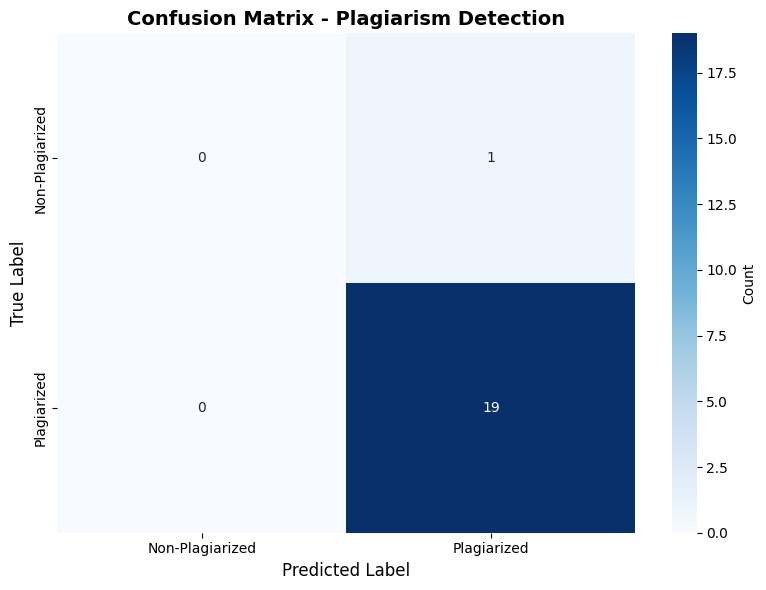

In [14]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Plagiarized', 'Plagiarized'],
    yticklabels=['Non-Plagiarized', 'Plagiarized'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Plagiarism Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

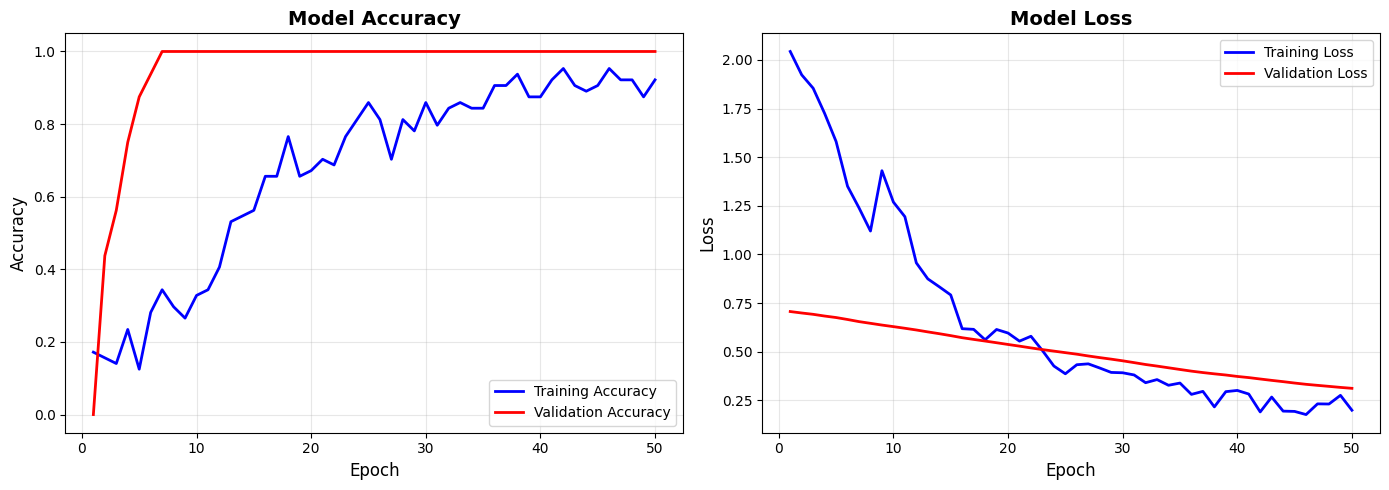

In [15]:
# Training History Visualization
acc = history.history['accuracy']
val_acc = history.history.get('val_accuracy', [])
loss = history.history['loss']
val_loss = history.history.get('val_loss', [])
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
if val_acc:
    ax1.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
if val_loss:
    ax2.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Category-wise Performance Analysis

In [16]:
print("\n[STEP 9] Analyzing performance by plagiarism category...\n")

# Get test indices to map back to original data
test_indices = corpus_df.index[-len(X_test):]
test_df = corpus_df.iloc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['probability'] = y_pred_prob.flatten()

# Performance by category
print("="*60)
print("PERFORMANCE BY CATEGORY")
print("="*60)

for category in sorted(test_df['category'].unique()):
    cat_df = test_df[test_df['category'] == category]
    cat_acc = accuracy_score(cat_df['label'], cat_df['predicted'])
    
    print(f"\nCategory: {category}")
    print(f"  Samples: {len(cat_df)}")
    print(f"  Accuracy: {cat_acc*100:.2f}%")
    print(f"  Avg Confidence: {cat_df['probability'].mean():.4f}")


[STEP 9] Analyzing performance by plagiarism category...

PERFORMANCE BY CATEGORY

Category: cut
  Samples: 3
  Accuracy: 100.00%
  Avg Confidence: 0.7187

Category: heavy
  Samples: 3
  Accuracy: 100.00%
  Avg Confidence: 0.7174

Category: light
  Samples: 3
  Accuracy: 100.00%
  Avg Confidence: 0.7189

Category: non
  Samples: 6
  Accuracy: 100.00%
  Avg Confidence: 0.7358

Category: orig
  Samples: 5
  Accuracy: 0.00%
  Avg Confidence: 0.7188


## Step 9: Final Summary

In [17]:
# Final Summary
print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print(f"\nFinal Results:")
print(f"  - Total Samples: {len(corpus_df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")
print(f"  - Test Accuracy: {test_acc*100:.2f}%")
print(f"  - Model Parameters: {model.count_params():,}")
print(f"  - Embedding Dimensions: {X_train.shape[1]}")
print("\nModel is ready for plagiarism detection!")
print("="*60)


PROJECT COMPLETED SUCCESSFULLY

Final Results:
  - Total Samples: 100
  - Training Samples: 80
  - Test Samples: 20
  - Test Accuracy: 95.00%
  - Model Parameters: 143,617
  - Embedding Dimensions: 384

Model is ready for plagiarism detection!


## Optional: Test with Custom Text

In [18]:
def predict_plagiarism(text):
    """Predict if a given text is plagiarized."""
    # Preprocess
    cleaned = advanced_text_preprocessing(text)
    # Encode
    embedding = sbert_model.encode([cleaned])
    # Predict
    prob = model.predict(embedding, verbose=0)[0][0]
    prediction = "Plagiarized" if prob > 0.5 else "Non-Plagiarized"
    
    print(f"Text: {text[:100]}...")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {prob*100 if prob > 0.5 else (1-prob)*100:.2f}%")
    print("-" * 50)
    return prediction, prob

# Test examples
print("\n" + "="*60)
print("TESTING CUSTOM TEXT")
print("="*60 + "\n")

test_texts = [
    "This is an original piece of writing about artificial intelligence and its applications in modern society.",
    "This text is copied from another source and represents plagiarism."
]

for text in test_texts:
    predict_plagiarism(text)


TESTING CUSTOM TEXT

Text: This is an original piece of writing about artificial intelligence and its applications in modern so...
Prediction: Plagiarized
Confidence: 73.62%
--------------------------------------------------
Text: This text is copied from another source and represents plagiarism....
Prediction: Plagiarized
Confidence: 74.99%
--------------------------------------------------


## Optional: Save the Model

In [19]:
# Save the trained model
model_save_path = 'plagiarism_detector_model.h5'
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# To load the model later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('plagiarism_detector_model.h5')

Model saved to: plagiarism_detector_model.h5
